# Tutorial 4: Spatial Statistics

**Duration:** 20-25 minutes

This tutorial covers classical spatial point pattern statistics for analyzing cell organization in tissue samples. You'll learn to detect clustering, dispersion, and cell-cell interactions.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Apply Ripley's K/L/H functions to test for spatial clustering
- Use cross-type statistics to analyze interactions between cell types
- Compute colocalization metrics and neighborhood enrichment
- Detect spatial hotspots using Getis-Ord statistics
- Interpret results in biological context

## Prerequisites

- Tutorials 1-3 completed
- Understanding of null hypothesis testing
- Familiarity with the concept of Complete Spatial Randomness (CSR)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.statistics import (
    # Ripley's functions
    ripleys_k,
    ripleys_l,
    ripleys_h,
    csr_envelope,
    # Cross-type functions
    cross_k,
    cross_h,
    # Colocalization
    colocalization_quotient,
    colocalization_matrix,
    neighborhood_enrichment_test,
    morans_i,
    # Hotspots
    getis_ord_gi_star,
    detect_hotspots,
    local_morans_i,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_ripleys_curve,
    plot_colocalization_heatmap,
    plot_hotspot_map,
)

np.random.seed(42)

### Create sample tissue with specific patterns

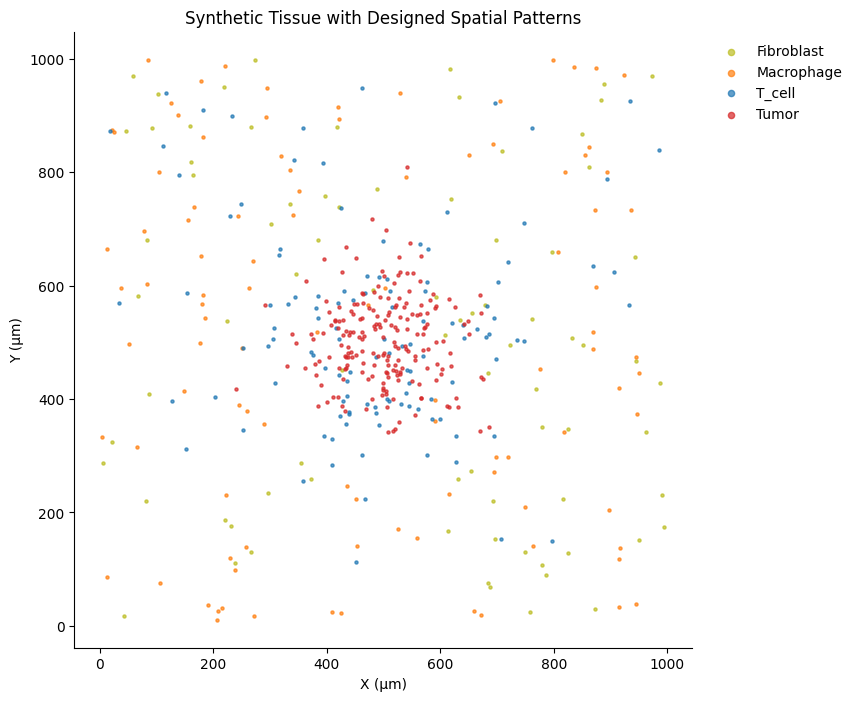

In [2]:
# Create clustered tumor cells
tumor_coords = np.random.normal(loc=[500, 500], scale=80, size=(200, 2))
tumor_types = ['Tumor'] * 200

# Create T cells that infiltrate the tumor (attracted to tumor)
tcell_near_tumor = np.random.normal(loc=[500, 500], scale=120, size=(80, 2))
tcell_far = np.random.uniform(0, 1000, size=(40, 2))
tcell_coords = np.vstack([tcell_near_tumor, tcell_far])
tcell_types = ['T_cell'] * 120

# Create macrophages that avoid tumor (repelled)
macro_coords = []
while len(macro_coords) < 100:
    candidate = np.random.uniform(0, 1000, size=2)
    dist_to_tumor_center = np.linalg.norm(candidate - [500, 500])
    if dist_to_tumor_center > 250 or np.random.random() < 0.1:
        macro_coords.append(candidate)
macro_coords = np.array(macro_coords)
macro_types = ['Macrophage'] * 100

# Create uniformly distributed fibroblasts (random/CSR)
fibro_coords = np.random.uniform(0, 1000, size=(80, 2))
fibro_types = ['Fibroblast'] * 80

# Combine
coordinates = np.vstack([tumor_coords, tcell_coords, macro_coords, fibro_coords])
cell_types = np.array(tumor_types + tcell_types + macro_types + fibro_types)

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)

fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Synthetic Tissue with Designed Spatial Patterns')
plt.show()

## Section 1: Ripley's K Function and Variants

Ripley's K function measures the number of points within distance r of a typical point, compared to a random (CSR) distribution.

- **K(r) > πr²**: Clustering (more points nearby than expected)
- **K(r) = πr²**: Complete Spatial Randomness
- **K(r) < πr²**: Regularity/dispersion (fewer points nearby)

### 1.1 Basic Ripley's K

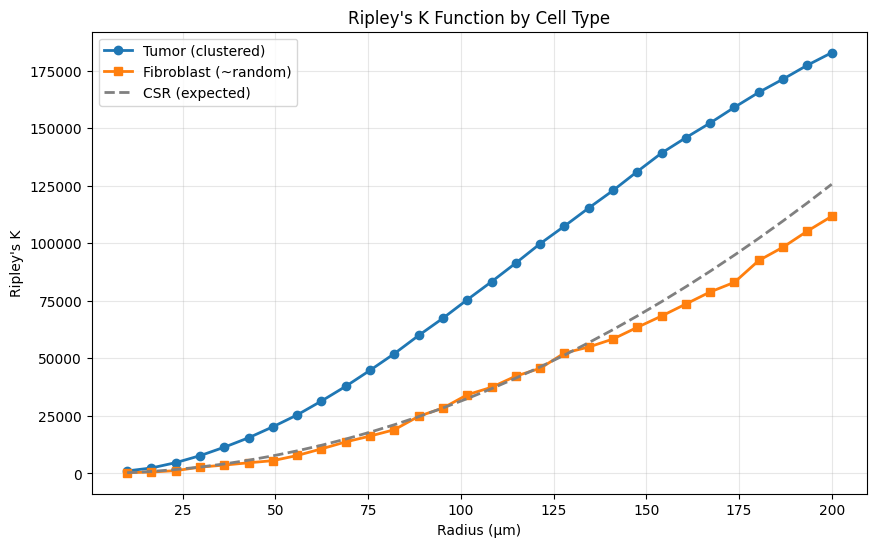

In [3]:
# Define radii to analyze
radii = np.linspace(10, 200, 30)

# Compute K for tumor cells
tumor_mask = tissue.cell_types == 'Tumor'
tumor_coords = tissue.coordinates[tumor_mask]
K_tumor = ripleys_k(tumor_coords, radii=radii)

# Compute K for fibroblasts (should be ~random)
fibro_mask = tissue.cell_types == 'Fibroblast'
fibro_coords = tissue.coordinates[fibro_mask]
K_fibro = ripleys_k(fibro_coords, radii=radii)

# Expected K under CSR
K_csr = np.pi * radii**2

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(radii, K_tumor, 'o-', label='Tumor (clustered)', linewidth=2)
ax.plot(radii, K_fibro, 's-', label='Fibroblast (~random)', linewidth=2)
ax.plot(radii, K_csr, '--', label='CSR (expected)', linewidth=2, color='gray')
ax.set_xlabel('Radius (μm)')
ax.set_ylabel("Ripley's K")
ax.legend()
ax.set_title("Ripley's K Function by Cell Type")
ax.grid(alpha=0.3)
plt.show()

### 1.2 Ripley's H Function (Variance-Stabilized)

H(r) = L(r) - r, where L(r) = √(K(r)/π). This transformation makes interpretation easier:
- H(r) > 0: Clustering
- H(r) = 0: Random
- H(r) < 0: Dispersion

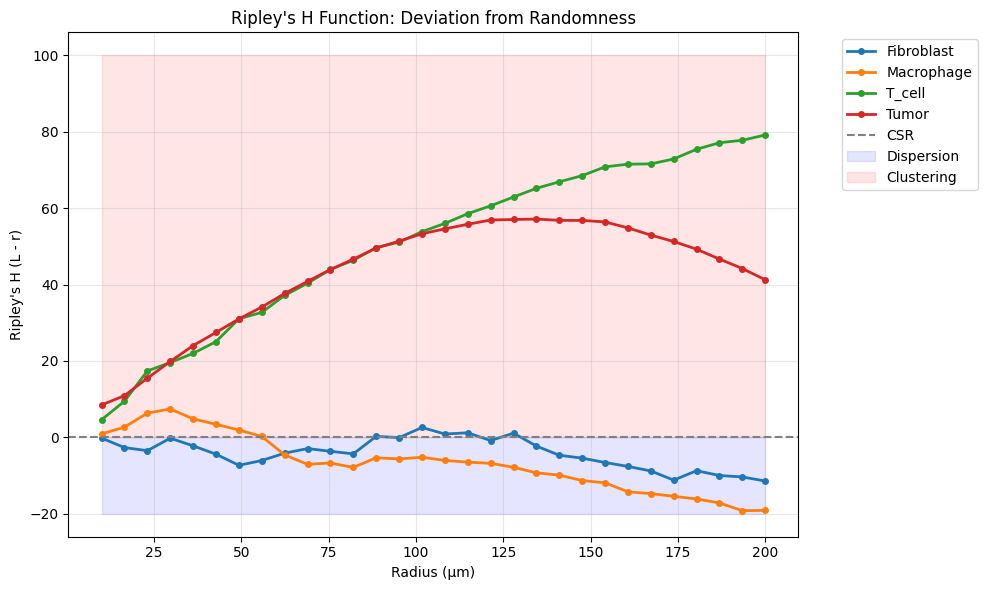

In [4]:
# Compute H for all cell types
cell_type_H = {}
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    coords = tissue.coordinates[mask]
    if len(coords) >= 10:  # Need enough points
        cell_type_H[ct] = ripleys_h(coords, radii=radii)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
for ct, H in cell_type_H.items():
    ax.plot(radii, H, 'o-', label=ct, linewidth=2, markersize=4)

ax.axhline(0, color='gray', linestyle='--', label='CSR')
ax.fill_between(radii, -20, 0, alpha=0.1, color='blue', label='Dispersion')
ax.fill_between(radii, 0, 100, alpha=0.1, color='red', label='Clustering')
ax.set_xlabel('Radius (μm)')
ax.set_ylabel("Ripley's H (L - r)")
ax.legend(bbox_to_anchor=(1.05, 1))
ax.set_title("Ripley's H Function: Deviation from Randomness")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Monte Carlo Significance Testing

Compare observed values to a null distribution from CSR simulations:

In [24]:
# calculate the tissue area
tissue_width = tissue.bounds['x'][1] - tissue.bounds['x'][0]
tissue_length = tissue.bounds['y'][1] - tissue.bounds['y'][0]
tissue_area = np.ceil(tissue_width * tissue_length)

# Generate CSR envelope for tumor cells
envelope = csr_envelope(
    tumor_coords,
    radii=radii,
    area=tissue_area,
    n_simulations=99
)

# Plot with envelope
fig, ax = plt.subplots(figsize=(10, 6))

# Envelope
ax.fill_between(radii, envelope['lower'], envelope['upper'], 
                alpha=0.3, color='gray', label='95% CSR envelope')
ax.plot(radii, envelope['expected'], '--', color='gray', label='Expected (CSR)')

# Observed
ax.plot(radii, cell_type_H['Tumor'], 'o-', color='red', linewidth=2, label='Tumor (observed)')

ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Radius (μm)')
ax.set_ylabel("Ripley's H")
ax.legend()
ax.set_title('Significance Testing: Tumor Cell Clustering')
ax.grid(alpha=0.3)
plt.show()

print("Interpretation: Points outside the envelope indicate significant deviation from CSR")

TypeError: only integer scalar arrays can be converted to a scalar index

## Section 2: Cross-Type Spatial Statistics

Cross-type functions measure spatial relationships between two different cell types.

### 2.1 Cross-K Function

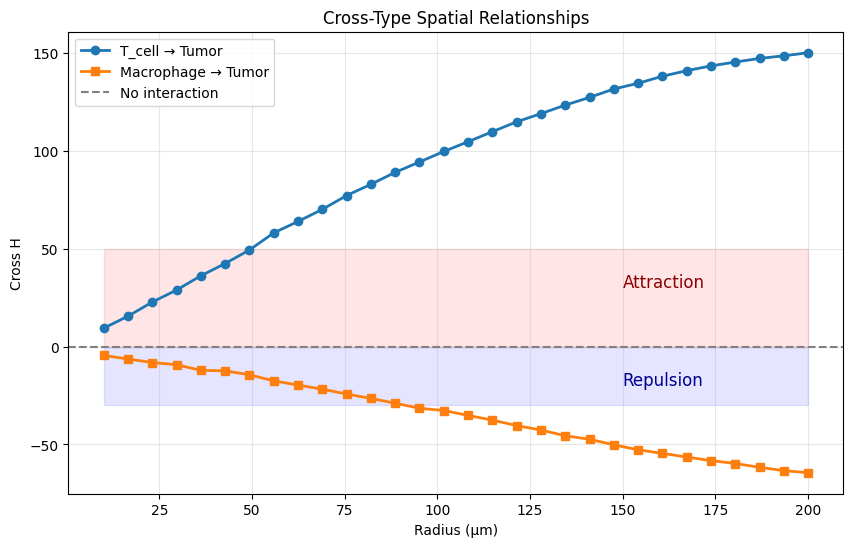

T cells are ATTRACTED to tumor (positive H)
Macrophages are REPELLED by tumor (negative H)


In [35]:
# Get the coordinates for different cell types of interest
tumor_coords = tissue.coordinates[tissue.get_cells_by_type('Tumor')]
tcell_coords = tissue.coordinates[tissue.get_cells_by_type('T_cell')]
macrophage_coords = tissue.coordinates[tissue.get_cells_by_type('Macrophage')]

# Cross-H between T cells and Tumor cells
H_tcell_tumor = cross_h(
    coords_a=tumor_coords,
    coords_b=tcell_coords,
    radii=radii
)

# Cross-H between Macrophages and Tumor cells
H_macro_tumor = cross_h(
    coords_a=macrophage_coords,
    coords_b=tumor_coords,
    radii=radii
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(radii, H_tcell_tumor, 'o-', label='T_cell → Tumor', linewidth=2)
ax.plot(radii, H_macro_tumor, 's-', label='Macrophage → Tumor', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', label='No interaction')
ax.fill_between(radii, -30, 0, alpha=0.1, color='blue')
ax.fill_between(radii, 0, 50, alpha=0.1, color='red')
ax.set_xlabel('Radius (μm)')
ax.set_ylabel("Cross H")
ax.legend()
ax.set_title('Cross-Type Spatial Relationships')
ax.text(150, 30, 'Attraction', fontsize=12, color='darkred')
ax.text(150, -20, 'Repulsion', fontsize=12, color='darkblue')
ax.grid(alpha=0.3)
plt.show()

print("T cells are ATTRACTED to tumor (positive H)")
print("Macrophages are REPELLED by tumor (negative H)")

## Section 3: Colocalization Analysis

### 3.1 Colocalization Quotient (CLQ)

In [7]:
# Compute pairwise colocalization
clq_matrix = colocalization_matrix(tissue, radius=50.0)

print("Colocalization Quotient Matrix (radius=50μm):")
print(clq_matrix.round(2))
print("\nInterpretation:")
print("  CLQ > 1: Attraction (found together more than expected)")
print("  CLQ = 1: No preference")
print("  CLQ < 1: Repulsion (found together less than expected)")

Colocalization Quotient Matrix (radius=50μm):
            Fibroblast  Macrophage  T_cell  Tumor
Fibroblast        2.29        1.00    0.92   0.72
Macrophage        1.00        2.34    0.66   0.52
T_cell            0.92        0.66    4.20   4.89
Tumor             0.72        0.52    4.89  13.03

Interpretation:
  CLQ > 1: Attraction (found together more than expected)
  CLQ = 1: No preference
  CLQ < 1: Repulsion (found together less than expected)


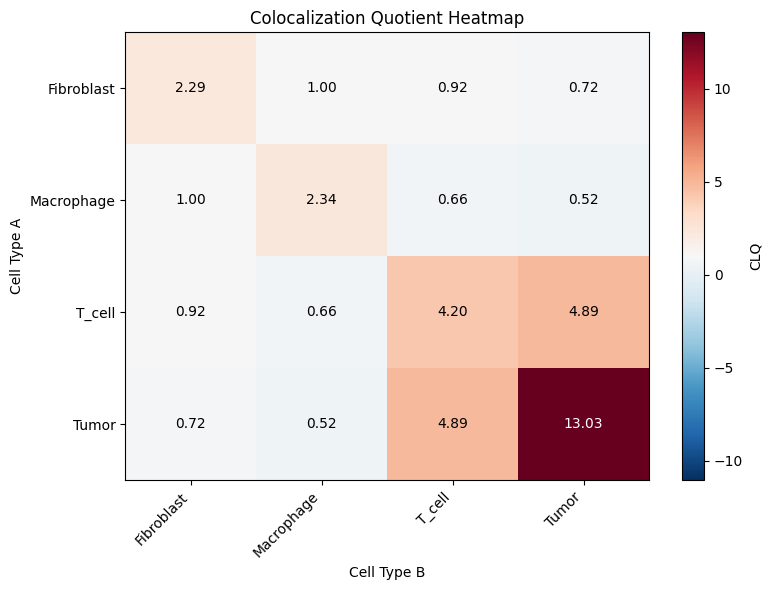

In [37]:
# Visualize colocalization matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_colocalization_heatmap(tissue, ax=ax)
ax.set_title('Colocalization Quotient Heatmap')
plt.tight_layout()
plt.show()

### 3.2 Neighborhood Enrichment Test

Statistical test for significant enrichment/depletion:

In [39]:
# Test enrichment with permutation test
enrichment_result = neighborhood_enrichment_test(
    tissue,
    type_a='T_cell',
    type_b='Tumor',
    radius=50.0,
    n_permutations=999
)

print("Neighborhood Enrichment Test: T_cell near Tumor")
print(f"  Observed count: {enrichment_result['observed']:.1f}")
print(f"  Expected (null): {enrichment_result['expected']:.1f}")
print(f"  Z-score: {enrichment_result['zscore']:.2f}")
print(f"  P-value: {enrichment_result['pvalue']:.4f}")
print(f"  Significant: {enrichment_result['pvalue'] < 0.05}")

Neighborhood Enrichment Test: T_cell near Tumor
  Observed count: 944.0
  Expected (null): 685.6
  Z-score: 5.08
  P-value: 0.0010
  Significant: True


## Section 4: Hotspot Detection

### 4.1 Getis-Ord Gi* Statistic

Identifies locations with statistically significant clustering of high (hotspot) or low (coldspot) values.

In [40]:
# Create a synthetic marker expression pattern
# Higher expression near tumor center
distances_to_center = np.linalg.norm(tissue.coordinates - [500, 500], axis=1)
marker_expression = 100 * np.exp(-distances_to_center / 200) + np.random.normal(0, 10, len(tissue.coordinates))
marker_expression = np.clip(marker_expression, 0, None)

# Compute Gi* statistics
gi_star = getis_ord_gi_star(
    tissue,
    values=marker_expression,
    radius=50.0
)

print(f"Gi* statistics range: [{gi_star.min():.2f}, {gi_star.max():.2f}]")
print(f"Hotspots (Gi* > 2): {np.sum(gi_star > 2)} cells")
print(f"Coldspots (Gi* < -2): {np.sum(gi_star < -2)} cells")

Gi* statistics range: [-3.32, 10.67]
Hotspots (Gi* > 2): 205 cells
Coldspots (Gi* < -2): 63 cells


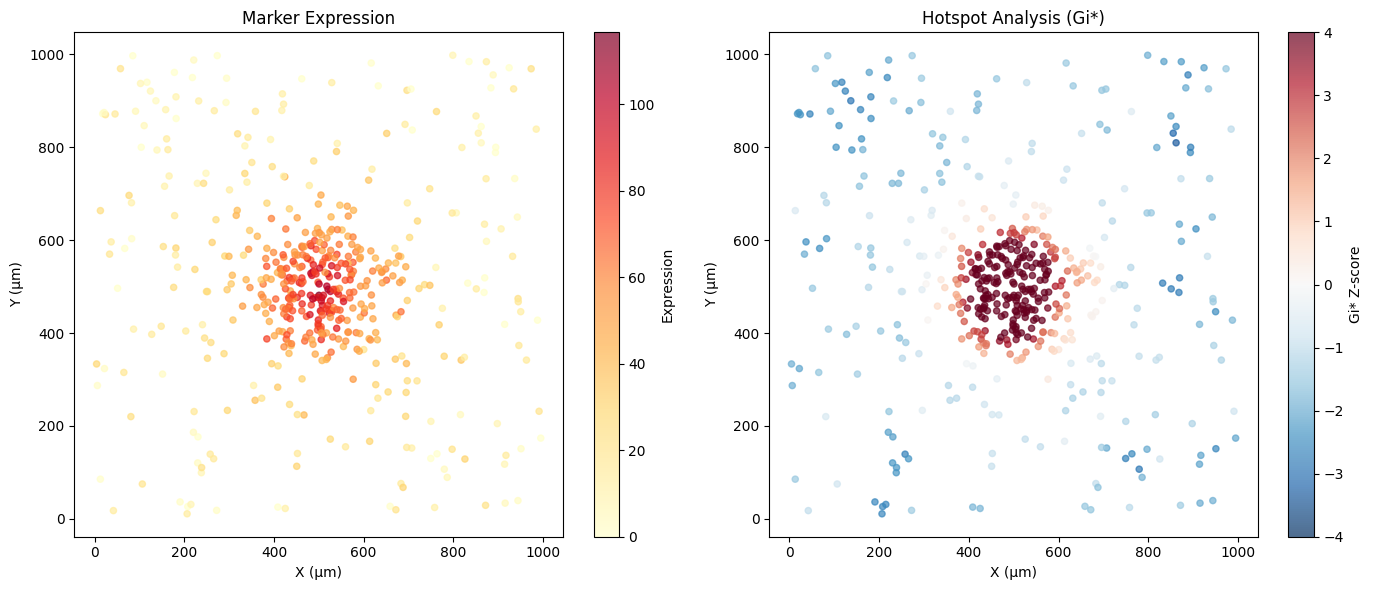

In [41]:
# Visualize hotspots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Raw marker expression
scatter1 = axes[0].scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=marker_expression,
    cmap='YlOrRd',
    s=20,
    alpha=0.7
)
plt.colorbar(scatter1, ax=axes[0], label='Expression')
axes[0].set_title('Marker Expression')
axes[0].set_xlabel('X (μm)')
axes[0].set_ylabel('Y (μm)')

# Right: Gi* statistics (hotspots)
scatter2 = axes[1].scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=gi_star,
    cmap='RdBu_r',
    vmin=-4,
    vmax=4,
    s=20,
    alpha=0.7
)
plt.colorbar(scatter2, ax=axes[1], label='Gi* Z-score')
axes[1].set_title('Hotspot Analysis (Gi*)')
axes[1].set_xlabel('X (μm)')
axes[1].set_ylabel('Y (μm)')

plt.tight_layout()
plt.show()

### 4.2 Detecting Significant Hotspots

Significant hotspots: 187 cells
Significant coldspots: 44 cells


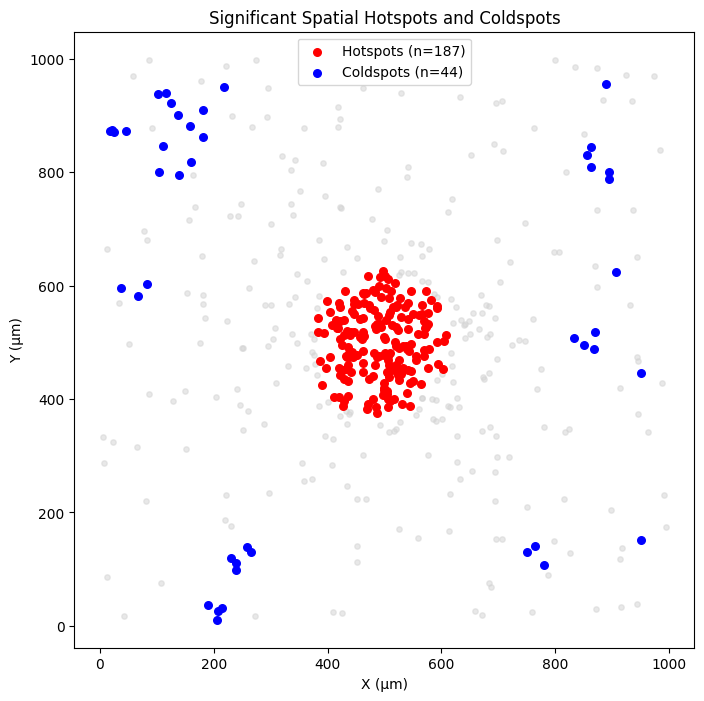

In [45]:
# Use convenience function to detect hotspots
hotspot_result = detect_hotspots(
    tissue,
    values=marker_expression,
    radius=50.0
)

print(f"Significant hotspots: {len(hotspot_result['hotspot_idx'])} cells")
print(f"Significant coldspots: {len(hotspot_result['coldspot_idx'])} cells")

# Visualize with hotspot highlighting
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c='lightgray',
    s=15,
    alpha=0.5
)
ax.scatter(
    tissue.coordinates[hotspot_result['hotspot_idx'], 0],
    tissue.coordinates[hotspot_result['hotspot_idx'], 1],
    c='red',
    s=30,
    label=f"Hotspots (n={len(hotspot_result['hotspot_idx'])})"
)
ax.scatter(
    tissue.coordinates[hotspot_result['coldspot_idx'], 0],
    tissue.coordinates[hotspot_result['coldspot_idx'], 1],
    c='blue',
    s=30,
    label=f"Coldspots (n={len(hotspot_result['coldspot_idx'])})"
)
ax.legend()
ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('Significant Spatial Hotspots and Coldspots')
plt.show()

### 4.3 Moran's I (Global Spatial Autocorrelation)

In [47]:
morans_result

{'I': 1.0944551438955783,
 'expected': -0.002004008016032064,
 'variance': 0.00014815309987411393,
 'zscore': 90.08180619141199,
 'pvalue': 0.0}

In [48]:
# Compute global Moran's I
morans_result = morans_i(
    tissue,
    values=marker_expression,
    radius=50.0
)

print("Moran's I (Global Spatial Autocorrelation):")
print(f"  I = {morans_result['I']:.4f}")
print(f"  Expected I = {morans_result['expected']:.4f}")
print(f"  Z-score = {morans_result['zscore']:.2f}")
print(f"  P-value = {morans_result['pvalue']:.4f}")
print("\nInterpretation:")
if morans_result['I'] > 0:
    print("  Positive I: Similar values cluster together (spatial autocorrelation)")
else:
    print("  Negative I: Dissimilar values are neighbors (checkerboard pattern)")

Moran's I (Global Spatial Autocorrelation):
  I = 1.0945
  Expected I = -0.0020
  Z-score = 90.08
  P-value = 0.0000

Interpretation:
  Positive I: Similar values cluster together (spatial autocorrelation)


## Exercise: Analyze Real Patterns

Try the following:

1. **Multi-scale analysis:** Compute Ripley's H at different radii (10, 50, 100, 200 μm). At what scale do you see the strongest clustering?

2. **Asymmetric interactions:** Is the CLQ between A→B the same as B→A? Compare CLQ(T_cell→Tumor) with CLQ(Tumor→T_cell).

3. **Cell type hotspots:** Instead of marker expression, use a binary vector (1 for T_cells, 0 for others) to find hotspots of T_cell density.

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Ripley's functions:** K, L, and H for detecting single-type clustering
- **Cross-type statistics:** Measuring attraction/repulsion between cell types
- **Colocalization:** CLQ and neighborhood enrichment for interaction analysis
- **Hotspot detection:** Getis-Ord Gi* and Moran's I for spatial autocorrelation
- **Significance testing:** Monte Carlo envelopes and permutation tests

## Next Steps

- **Tutorial 5: Neighborhoods** - Deep dive into neighborhood composition analysis
- **Tutorial 6: Networks** - Graph-based spatial analysis